In [1]:
%run general_functions.ipynb

In [2]:
def horizontal_weights(data, var, mask, mask_var, oper):

    weights = mask[mask_var].fillna(0)
    if oper == 'ave':
        data_weighted = data.weighted(weights).mean(('x','y'))
    elif oper == 'sum':
        data_weighted = data.weighted(weights).sum(('x','y'))
    
    return data_weighted

In [3]:
def lin_regr(data, var):
    
    t = np.arange(len(data.time_counter))
    y = data[var]
    slope, intercept, r_value, p_value, std_err = linregress(t, y)
    y_pred = intercept + slope * t
    
    return y_pred

In [4]:
def fig_plot_map(data, var, ax, vmin, vmax, oae_index, base_index):
    # get the difference between oae and baseline over time, then compute the 10-year mean
    if var != 'DIC':
        da = ((list(data.values())[oae_index]-list(data.values())[base_index]).mean('year'))[var]
    else:
        da = (list(data.values())[oae_index].isel(year=-1)-list(data.values())[base_index].isel(year=-1))[var]

    lon, lat = da['nav_lon'].mean('y'), da['nav_lat'].mean('x')
    im = ax.pcolormesh(lon, lat,
        da,
        cmap=cmap,
        vmin=vmin,vmax=vmax,)

    return im

started preprocessing for lineplot


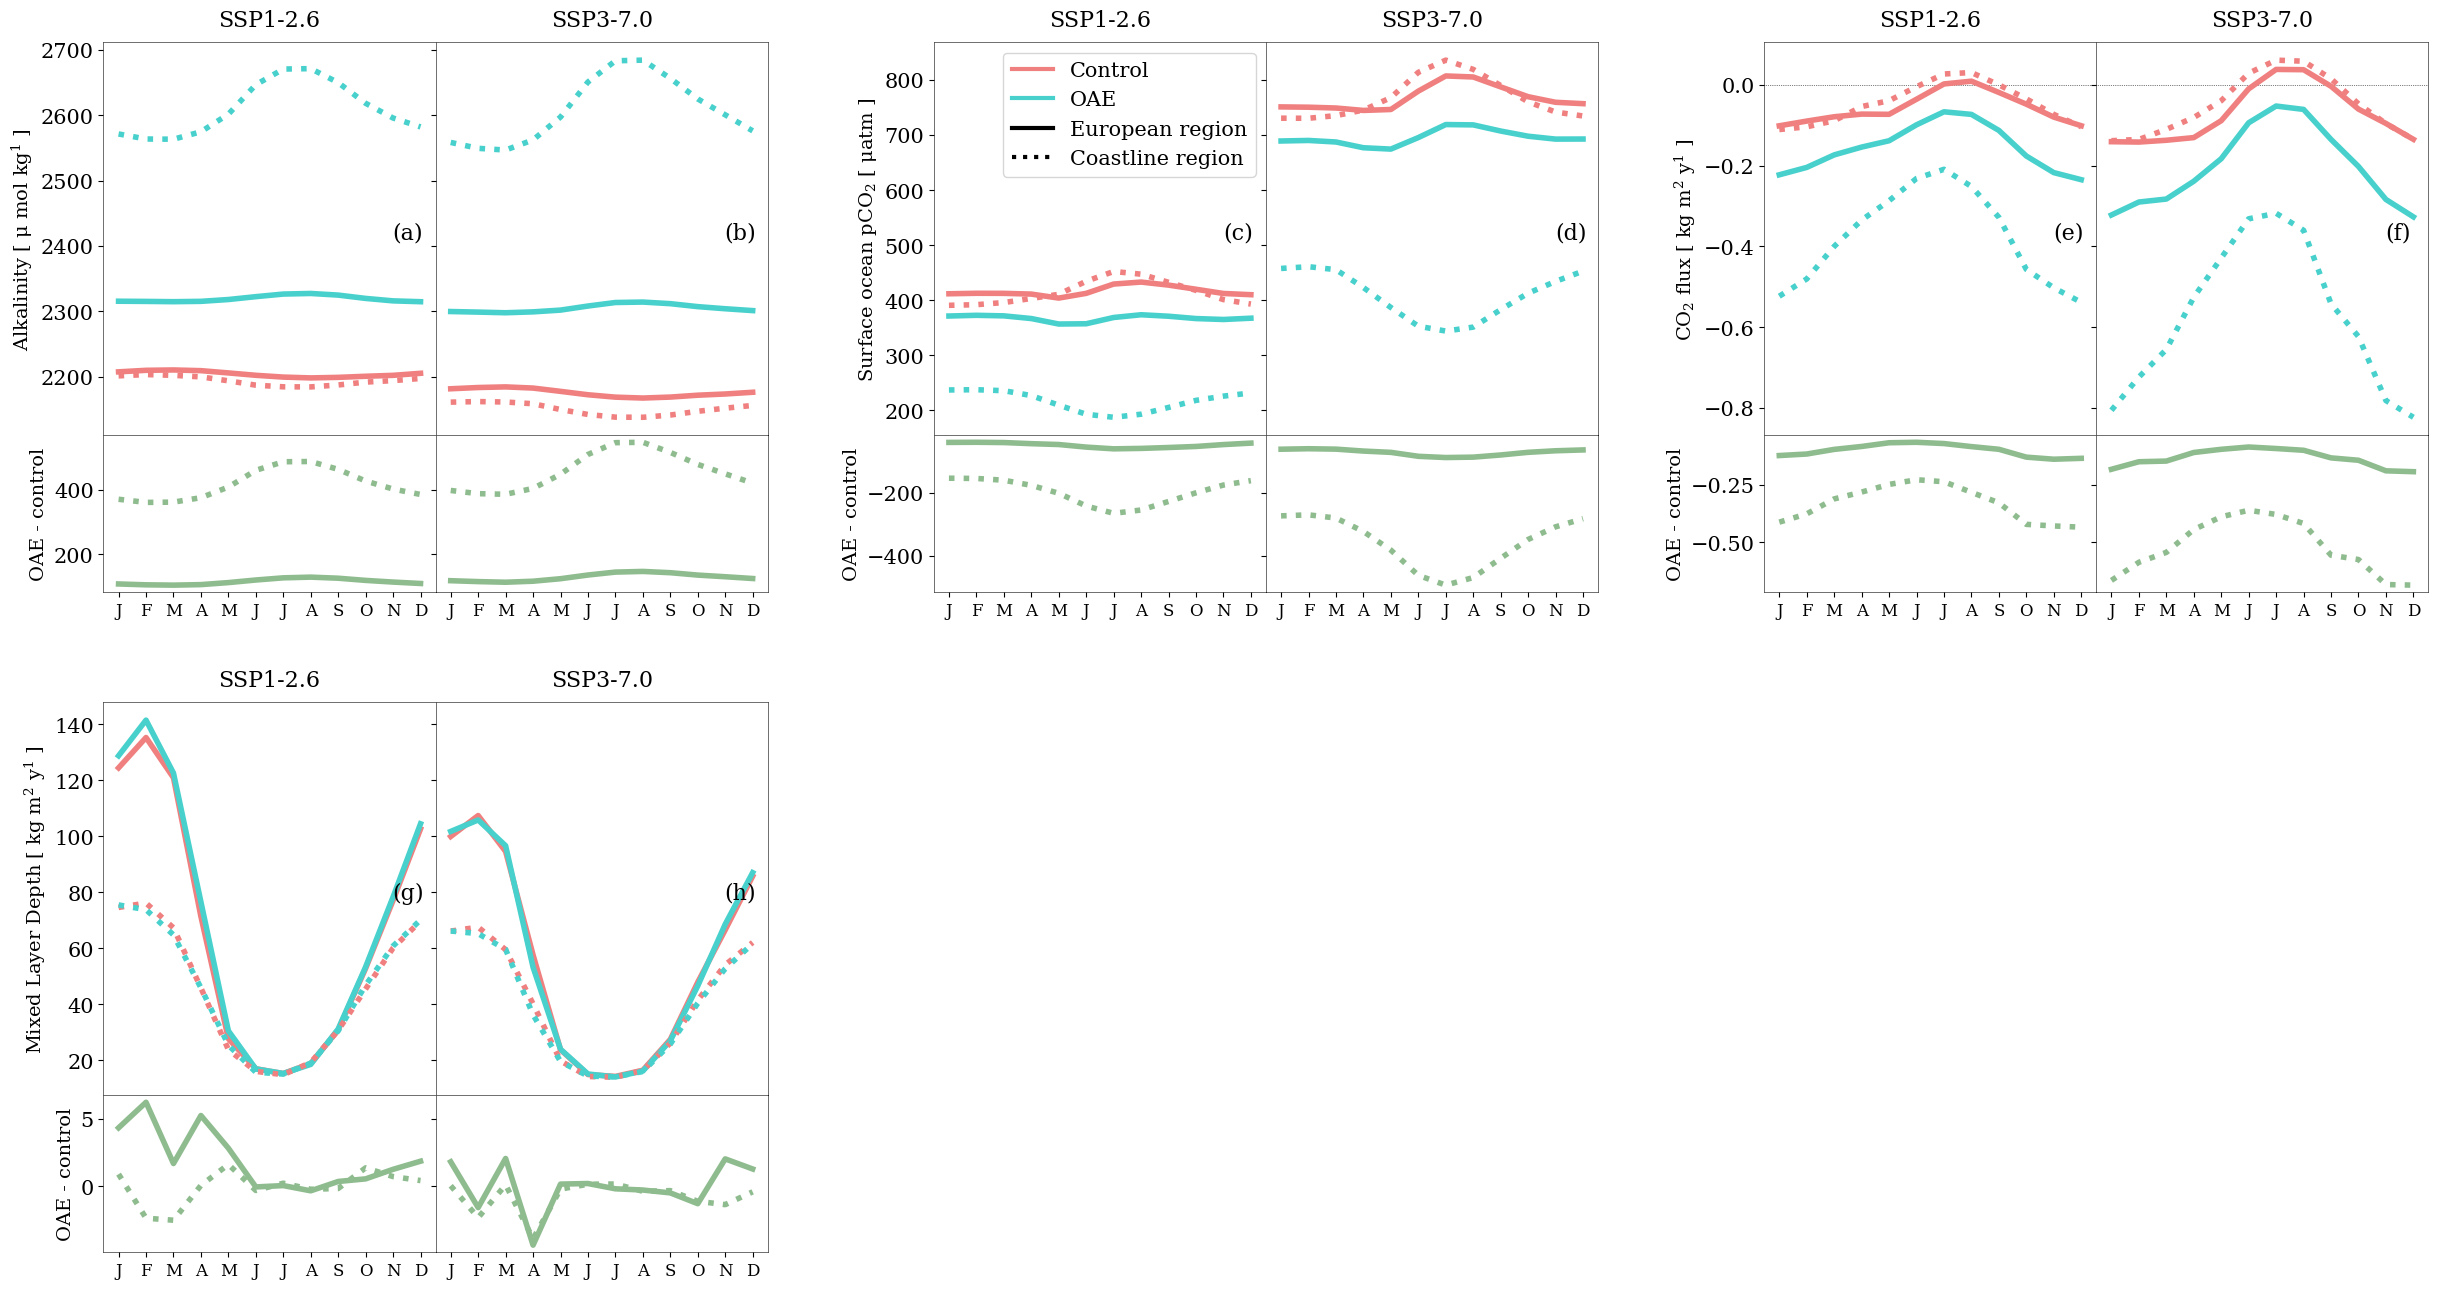

In [18]:
# -----------------------------
# figures = {'lineplot':3,'map':5,'scatter':6}
figures = {'lineplot':3,'map':5}
figures = {'lineplot':3}
# -----------------------------

# variable names
vars = {
            'ALK':     {'var_name': 'ALK',      'long': 'Alkalinity',                                                    'unit': r'μ mol $\mathregular{kg^{1}}$',      'value':400, 'df_unit':'μmol $\mathregular{kg^{1}}$',    'df_name' : 'Alkalinity'},
            'fco2':    {'var_name': 'fco2',     'long': 'Surface ocean p$\mathregular{CO_{2}}$',                         'unit': r'μatm',                               'value':200, 'df_unit':'μatm',         'df_name' : 'Surface ocean p$\mathregular{CO_{2}}$'},
            'co2flux': {'var_name': 'co2flux',  'long': '$\mathregular{CO_{2}}$ flux',           'conv_term':'31536000', 'unit': r'kg $\mathregular{m^{2} \ y^{1}}$', 'value':1,   'df_unit':'kg $\mathregular{m^{2} \ y^{1}}$', 'df_name' : 'Air-sea $\mathregular{CO_{2}}$ flux'},
    
            # 'ph':      {'var_name': 'ph',       'long': 'pH',                                                            'unit': '-',                                   'value':.05, 'df_unit':r'μmol $\mathregular{kg^{1}}$',    'df_name' : 'pH'},
            # 'DIC':     {'var_name': 'DIC',      'long': 'DIC',                                                           'unit': r'μ mol $\mathregular{kg^{1}}$',      'value':400, 'df_unit':'units',        'df_name' : 'Dissolved Inorganic Carbon'},
            'somxl010':{'var_name': 'somxl010', 'long': 'Mixed Layer Depth',                                             'unit': r'kg $\mathregular{m^{2} \ y^{1}}$', 'value':1,   'df_unit':'m',            'df_name' : 'Mixed layer depth'},
}

mlds = {     
            'somxl010':{'var_name': 'somxl010', 'long': 'Mixed Layer Depth',                                             'unit': r'm'}
}

scenarios = {'126' : 'SSP1-2.6', '370': 'SSP3-7.0'}
runs = {'baseline' : 'Control', 'oae' : 'OAE'}

for fig, n in figures.items():

    print(f'started preprocessing for {fig}')
    
    mesh_mask = xr.open_dataset(data_path+'mesh_mask.nc')
    polygon_boundaries = polygon_mask(mesh_mask)
    mesh = (mesh_mask['tmask'] * polygon_boundaries)

    var = 'fco2'
    ocn_mask = ocean_mask(data_path, var)
    cst_mask = coastline_mask(data_path + '../alk_mask/', var)
    
    def seasonal_analysis(mask, mask_var, location):
        mld_datasets = {}
        for scen, scen_key in scenarios.items():
            mld_datasets[scen] = {}
            for mld, mld_keys in mlds.items():
                mld_datasets[scen][mld] = {}
                for run, run_key in runs.items():
                    mld_datasets[scen][mld][run] = data_path + mld + f'_{run}_{scen}.nc'
    
        file_path = {}
        amplitude_line = {}
        amplitude_map = {}
        mld_ampl_line = {}
        data_early = {}
        
        for scen, scen_key in scenarios.items():
            
            file_path[scen] = {}
            amplitude_line[scen] = {}
            amplitude_map[scen] = {}
            mld_ampl_line[scen] = {}
            data_early[scen] = {}
           
            for var, keys in vars.items():
                file_path[scen][var] = {}
                amplitude_line[scen][var] = {}
                amplitude_map[scen][var] = {}
                mld_ampl_line[scen]['mld'] = {}
                data_early[scen][var] = {}
                
                for run, run_key in runs.items():
                    data = xr.open_dataset(data_path + var + f'_{run}_{scen}.nc')
                    data_mld = xr.open_dataset(mld_datasets[scen][mld][run])

                    var = keys['var_name']
                    if var in ['sosstsst','bgc_diag_pp']:
                        mesh_sliced = mesh.sel(x=slice(519, 595), y=slice(329, 435))
                    else:
                        mesh_sliced = mesh.sel(x=slice(520, 595), y=slice(330, 435))
                    conv_term = eval(vars[var].get('conv_term')) if 'conv_term' in vars[var].keys() else 1
        
                    mesh_sliced = mesh_sliced.where(mesh_sliced)
                    data = data * mesh_sliced.isel(t=0,z=0) * conv_term
    
                    if var in ['ALK','DIC']:
                        if fig == 'lineplot':
                            data = data.isel(deptht=0)
        
                        elif fig in ['map','scatter']:
                            data[var] = data[var].where(data['deptht'] < data_mld['somxl010'])
                            data = vertical_weights(data, var, data_mld, 'somxl010', 'ave')

                    data = data.where(mask[mask_var]>0)
                    data_early[scen][var][run] = data
                            
                    data_line = horizontal_weights(data, var, mask, mask_var, 'ave')
                    data_line = seasonal_avg(data_line, var)
                    amplitude_line[scen][var][run] = data_line
    
                    mld_line = horizontal_weights(data_mld, 'somxl010', mask, mask_var, 'ave')
                    mld_line = seasonal_avg(mld_line, 'somxl010')
                    mld_ampl_line[scen]['mld'][run] = mld_line
    
                    data_map = ((data.groupby('time_counter.year').max(dim='time_counter'))-(data.groupby('time_counter.year').min(dim='time_counter'))).mean('year')
                    amplitude_map[scen][var][run] = data_map
                    
                control, oae = runs.keys()
                amplitude_line[scen][var]['delta'] = amplitude_line[scen][var][oae] - amplitude_line[scen][var][control]
                mld_ampl_line[scen]['mld']['delta'] = mld_ampl_line[scen]['mld'][oae] - mld_ampl_line[scen]['mld'][control]
                amplitude_map[scen][var]['delta'] = amplitude_map[scen][var][oae] - amplitude_map[scen][var][control]
                data_early[scen][var]['delta'] = data_early[scen][var][oae] - data_early[scen][var][control] 

        return amplitude_line, amplitude_map, mesh_sliced, mld_ampl_line, data_early 
        
    europe, amplitude_map_europe, mesh_sliced, mld_ampl_europe, data_europe = seasonal_analysis(ocn_mask, 'tmask', 'europe')
    coast, amplitude_map_coast, mesh_sliced, mld_ampl_coast, data_coast = seasonal_analysis(cst_mask, 'alk_flux', 'coastline')
    
    # LINEPLOT
    
    s_126, s_370 = scenarios.keys()
    r_control, r_oae = runs.keys()
    
    if fig == 'lineplot':
        fig = plt.figure(figsize=(30, 50))
        gs0 = gridspec.GridSpec(6, 3, hspace=0.2, wspace=0.25)
        
        colors = {'control': 'lightcoral', 'oae': 'mediumturquoise'}
        delta_color = 'darkseagreen'
        lw = 4
        
        axes = []
        
        def plot_main(ax, scen, var):
            
            if var == 'co2flux':
                ax.axhline(y=0, color='black', linestyle=':', lw=0.5)
                
            ax.plot(europe[scen][var][r_control][var],
                    color=colors['control'], lw=lw)
            ax.plot(europe[scen][var][r_oae][var],
                    color=colors['oae'], lw=lw)
        
            ax.plot(coast[scen][var][r_control][var],
                    color=colors['control'], ls=':', lw=lw)
            ax.plot(coast[scen][var][r_oae][var],
                    color=colors['oae'], ls=':', lw=lw)
        
        def plot_delta(ax, scen, var):
            ax.plot(europe[scen][var]['delta'][var],
                    color=delta_color, lw=lw)
            ax.plot(coast[scen][var]['delta'][var],
                    color=delta_color, ls=':', lw=lw)
            
#             if var in ['ALK','co2flux','fco2']:
#                 ax2 = ax.twinx()
#                 ax2.plot(mld_ampl_europe[scen]['mld']['delta']['somxl010'],
#                         color='goldenrod', lw=2)
#                 ax2.plot(mld_ampl_coast[scen]['mld']['delta']['somxl010'],
#                         color='goldenrod', ls=':', lw=2)

#                 ax2.set_ylim(-4,8)
#                 ax2.tick_params(axis='both', colors='goldenrod') 
#                 ax2.set_ylabel('MLD [ m ]', fontsize=14, color='goldenrod')
#                 fineline(ax2,0.4)            
        
        for row, (var, keys) in enumerate(vars.items()):
            long = keys['long']
            unit = keys['unit']
        
            gs = gridspec.GridSpecFromSubplotSpec(
                2, 2,
                subplot_spec=gs0[row],
                height_ratios=[1, 0.4],
                width_ratios=[1, 1],
                hspace=0,
                wspace=0
            )
        
            row_axes = []
        
            for col, scen in enumerate(scenarios.keys()):
                ax_top = fig.add_subplot(gs[0, col])
                ax_bot = fig.add_subplot(gs[1, col], sharex=ax_top)
        
                if col == 1:
                    ax_top.sharey(row_axes[0])
                    ax_bot.sharey(row_axes[1])
                    ax_top.tick_params(labelleft=False)
                    ax_bot.tick_params(labelleft=False)
        
                plot_main(ax_top, scen, var)
                plot_delta(ax_bot, scen, var)
        
                ax_top.set_title(list(scenarios.values())[col], fontsize=16, y=1.02)
        
                row_axes.extend([ax_top, ax_bot])
        
            row_axes[0].set_ylabel(f"{long} [ {unit} ]", fontsize=14)
            row_axes[1].set_ylabel("OAE - control", fontsize=14)
        
            axes.extend(row_axes)
        
        # Styling
        for ax in axes:
            month_x_labels(ax)
            ax.tick_params(axis='both', which='major')
            fineline(ax, 0.4)
        
        # Legend once
        legend_handles = [
            Line2D([0], [0], color=colors['control'], lw=3, label='Control'),
            Line2D([0], [0], color=colors['oae'], lw=3, label='OAE'),
            Line2D([0], [0], color='black', lw=3, label='European region'),
            Line2D([0], [0], color='black', lw=3, ls=':', label='Coastline region')
        ]
        
        axes[4].legend(handles=legend_handles, loc='best')
        
        # Panel labels
        for n, ax in enumerate(axes[::2]):
            ax.text(
                0.87, 0.5,
                f"({string.ascii_lowercase[n]})",
                transform=ax.transAxes,fontsize=16
            )
        
    
    # MAP
    
    elif fig == 'map':
        
        fig, axes = plt.subplots(2,3, figsize=(28, 21))
        plt.subplots_adjust(wspace=0.11, hspace=0.09)
        plt.rcParams['axes.linewidth'] = .2
        
        cmap, norm = create_discrete_cmap(cm.prinsenvlag_r, 40)
        
        d = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/last_decade/ALK_baseline_126.nc')
        lon, lat = d['nav_lon'].mean('y'), d['nav_lat'].mean('x')
        
        for row, scen in enumerate(scenarios.keys()):
                    
            for col, (var, keys) in enumerate(vars.items()):

                v = keys['value']
                ax = axes[row][col]   # 2D structure preferred

                data = amplitude_map_europe[scen][var]['delta'][var]
                im = ax.pcolormesh(
                    lon,
                    lat,
                    data.where(data),
                    cmap=cmap,
                    vmin=-v, vmax=v
                )
        
                ax.set_title(
                    f"{vars[var]['long']} [ {vars[var]['unit']} ]",
                    pad=12
                )
                if row == 1:
                    ax.set_title('')
                    ax.set_xlabel('Longitude')

                    fig.colorbar(
                        im,
                        ax=axes[:,col],
                        orientation='horizontal',
                        pad=0.05,
                        extend='both',
                        aspect=14
                    )
                    
                if col == 0 :
                    ax.set_ylabel('Latitude')
                    ax.text(-37,50.5, f'{list(scenarios.values())[row]}', rotation=90, fontsize=22)
            
        axes = axes.flatten()
        for ax in axes:
            ax.contour(lon, lat, d['ALK'].isel(deptht=0,time_counter=0), levels=[3], colors='black', linewidths=.5)  
            cs = ax.contour(lon, lat, mesh_sliced.fillna(0).isel(t=0,z=20), levels=[0.4599365], colors='black', linewidths=.8, linestyles='--')
            ax.clabel(cs, fmt=lambda x: '627m', inline=True, fontsize=15)            
            fineline(ax, 0.4)
 
        for n, ax in enumerate(axes):
            ax.text(0.88, 0.9, f'({string.ascii_lowercase[n]})',
                    transform=ax.transAxes, color='black', fontsize=18)
        
        pass
                
    elif fig == 'scatter':
        
        lat_n = 60
        
        def scatter(data, var):

            subset_60_65 = data.where((data['nav_lat'] > 60) & (data['nav_lat'] < 65))
            subset_55_60 = data.where((data['nav_lat'] > 55) & (data['nav_lat'] < 60))
            subset_50_55 = data.where((data['nav_lat'] > 50) & (data['nav_lat'] < 55))
            subset_45_50 = data.where((data['nav_lat'] > 45) & (data['nav_lat'] < 50))
            subset_40_45 = data.where((data['nav_lat'] > 40) & (data['nav_lat'] < 45))

            # data_w = horizontal_weights(subset, var, ocn_mask, 'tmask', 'ave')
            # data_s = ((subset.groupby('time_counter.year').max(dim='time_counter'))-(subset.groupby('time_counter.year').min(dim='time_counter')))

            return subset_40_45, subset_45_50, subset_50_55, subset_55_60, subset_60_65
        
        for data, title in zip((data_europe, data_coast), ('European region','Coastline region')):

            fig, axes = plt.subplots(5,1, figsize=(14,28))
            axes = axes.flatten()
            
            for c, scen in zip(('peru','cornflowerblue'), (s_126, s_370)):

                data[scen]['ALK']['oae'] = (data[scen]['ALK']['oae'].groupby('time_counter.year').max(dim='time_counter'))-(data[scen]['ALK']['oae'].groupby('time_counter.year').min(dim='time_counter')).mean('year')
                data[scen]['ALK']['baseline'] = (data[scen]['ALK']['baseline'].groupby('time_counter.year').max(dim='time_counter'))-(data[scen]['ALK']['baseline'].groupby('time_counter.year').min(dim='time_counter')).mean('year')

                alk = data[scen]['ALK']['oae'] - data[scen]['ALK']['baseline']
                alk_40_45, alk_45_50, alk_50_55, alk_55_60, alk_60_65 = scatter(alk, 'ALK')

                data[scen]['fco2']['oae'] = (data[scen]['fco2']['oae'].groupby('time_counter.year').max(dim='time_counter'))-(data[scen]['fco2']['oae'].groupby('time_counter.year').min(dim='time_counter')).mean('year')
                data[scen]['fco2']['baseline'] = (data[scen]['fco2']['baseline'].groupby('time_counter.year').max(dim='time_counter'))-(data[scen]['fco2']['baseline'].groupby('time_counter.year').min(dim='time_counter')).mean('year')
                
                fco2 = data[scen]['fco2']['oae'] - data[scen]['fco2']['baseline']
                fco2_40_45, fco2_45_50, fco2_50_55, fco2_55_60, fco2_60_65 = scatter(fco2, 'fco2')
                
                markers = ['o','x','v','s','p']

                for ax, alk, fco2, marker in zip(axes, (alk_40_45, alk_45_50, alk_50_55, alk_55_60, alk_60_65),
                                             (fco2_40_45, fco2_45_50, fco2_50_55, fco2_55_60, fco2_60_65),
                                             markers):
                    
                    x = fco2['fco2'].values.flatten()
                    y = alk['ALK'].values.flatten()
                    im = ax.scatter(x, y, marker=marker, color=c, s=40)

                    ax.set_xlabel(f"{vars['ALK']['long']} [ {vars['ALK']['unit']} ]", fontsize=14)
                    ax.set_ylabel(f"{vars['fco2']['long']} [ {vars['fco2']['unit']} ]", fontsize=14)
                    ax.set_xlim(-250,250)
                    ax.set_ylim(-750,1250)

                    fineline(ax,0.4)

            legend_elements = [
                        Line2D([0], [0], marker='o', color='w', markerfacecolor='black', label=f'> {lat_n}{degree}', markersize=12),
                        Line2D([0], [0], marker='X', color='w', markerfacecolor='black', label=f'< {lat_n}{degree}', markersize=12),
                        Line2D([0], [0], color='peru', label='SSP1-2.6'),
                        Line2D([0], [0], color='cornflowerblue', label='SSP3-7.0'),
                    ]
            plt.savefig(f'/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/correlation{n}.png')
            # ax.set_title(title)
            # ax.legend(handles=legend_elements)
    
    plt.savefig(f'/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure{n}.png')

In [19]:
# SUMMARY TABLE

rows = []

for var, keys in vars.items():
    unit = keys['unit']
    row = {}
    if var in ['co2flux','ph']:
        round_n = 3
    else:
        round_n = None
    # Europe
    
    # SSP1-2.6
    row[("European region","SSP1-2.6", "Control")] = (round(
        np.min(europe["126"][var]["baseline"][var].values), round_n),
    round(
        np.max(europe["126"][var]["baseline"][var].values), round_n))
    
    row[("European region","SSP1-2.6", "OAE")] = (round(
        np.min(europe["126"][var]["oae"][var].values), round_n),
    round(
        np.max(europe["126"][var]["oae"][var].values), round_n))

    # SSP3-7.0
    row[("European region","SSP3-7.0", "Control")] = (round(
        np.min(europe["370"][var]["baseline"][var].values), round_n),
    round(
        np.max(europe["370"][var]["baseline"][var].values), round_n))
    
    row[("European region","SSP3-7.0", "OAE")] = (round(
        np.min(europe["370"][var]["oae"][var].values), round_n),
    round(
        np.max(europe["370"][var]["oae"][var].values), round_n))

    # Coastline
    
    # SSP1-2.6
    row[("Coastline region","SSP1-2.6", "Control")] = (round(
        np.min(coast["126"][var]["baseline"][var].values), round_n),
    round(
        np.max(coast["126"][var]["baseline"][var].values), round_n))
    
    row[("Coastline region","SSP1-2.6", "OAE")] = (round(
        np.min(coast["126"][var]["oae"][var].values), round_n),
    round(
        np.max(coast["126"][var]["oae"][var].values), round_n))

    # SSP3-7.0
    row[("Coastline region","SSP3-7.0", "Control")] = (round(
        np.min(coast["370"][var]["baseline"][var].values), round_n),
    round(
        np.max(coast["370"][var]["baseline"][var].values), round_n))
    
    row[("Coastline region","SSP3-7.0", "OAE")] = (round(
        np.min(coast["370"][var]["oae"][var].values), round_n),
    round(
        np.max(coast["370"][var]["oae"][var].values), round_n))
    
    rows.append(row)

units = [item['df_unit'] for item in vars.values()]
var_names = [item['df_name'] for item in vars.values()]

df = pd.DataFrame(rows, index=[f"{name} [{str(unit)}]" for name, unit in zip(var_names, units)])
# hierarchical columns
df.columns = pd.MultiIndex.from_tuples(df.columns)
df
# index label
# df.index.name = "Variable name [unit]"

# export)
df.to_excel("/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/Summary_table.xlsx", merge_cells=True)